In [ ]:
import torch
from torch.optim import Adam
from torch import nn
import matplotlib.pyplot as plt


In [ ]:
service = 'cuda' if torch.cuda.is_available() else 'cpu'


In [ ]:
def VGG_block(num_convs, out_channels):
  layers = []
  for _ in range(num_convs):
    layers.append(nn.LazyConv2d(out_channels, kernel_size=3, padding=1))
    layers.append(nn.ReLU())
  layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
  return nn.Sequential(*layers)

In [ ]:
def init_cnn(module):
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)

class VGG(nn.Module):
  def __init__(self, arch, lr=0.1, num_classes=10) -> None:
    super().__init__()
    blks = [VGG_block(pair[0], pair[1]) for pair in arch]
    self.net = nn.Sequential(
      *blks,
      nn.Flatten(),
      nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
      nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
      nn.LazyLinear(num_classes)
    )
    self.net.apply(init_cnn)
    self.net.to(service)

In [ ]:
conv_arch = ((1, 64), (1, 128), (2, 256))
VGG(conv_arch)

VGG(
  (net): Sequential(
    (0): Sequential(
      (0): LazyConv2d(0, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): LazyConv2d(0, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): LazyConv2d(0, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): LazyConv2d(0, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): LazyLinear(in_features=0, out_features=4096, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
    (7): LazyLinear(in_features=0, out_features=4096, bias=True)
    (8): ReLU

In [ ]:
from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torch.utils import data
trans = transforms.ToTensor()

mnist_train = FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.33MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.1MB/s]


In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
K = 2 # 設定 2 折交叉驗證
kfold = KFold(n_splits=K, shuffle=True, random_state=42)

# 用來記錄每一折的最終表現
all_fold_train_loss = []
all_fold_val_loss = []

batch_size, lr, num_epochs = 256, 0.1, 10

# 開始 K-Fold 迴圈 (這裡使用 kfold.split 取得索引)
for fold, (train_ids, val_ids) in enumerate(kfold.split(mnist_train)):
    print(f'\n=== 正在執行第 {fold + 1} 折 / 共 {K} 折 ===')

    # 1. 根據索引建立該折的子資料集(train_ids -> array of train_id)
    train_sub = Subset(mnist_train, train_ids)
    val_sub = Subset(mnist_train, val_ids)

    # 2. 建立該折的 DataLoader
    train_iter = DataLoader(train_sub, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_iter = DataLoader(val_sub, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    model = VGG(conv_arch).net
    trainer = torch.optim.SGD(model.parameters(), lr=0.1)
    loss = torch.nn.CrossEntropyLoss()

    # 用來記錄該折內部每個 Epoch 的進度
    train_loss_history = []
    val_loss_history = []

    for epoch in range(num_epochs):
        # --- 訓練階段 ---
        model.train()
        total_train_loss = 0.0
        total_train_samples = 0
        for X, y in train_iter:
            X = X.to(service)
            y = y.to(service)
            y_hat = model(X)
            l = loss(y_hat, y)
            trainer.zero_grad()
            l.mean().backward()
            trainer.step()

            total_train_loss += l.sum().item()
            total_train_samples += y.size(0)

        epoch_train_loss = total_train_loss / total_train_samples
        train_loss_history.append(epoch_train_loss)

        # --- 驗證階段 ---
        model.eval()
        total_val_loss = 0.0
        total_val_samples = 0

        with torch.no_grad():
            for X_val, y_val in val_iter:
                X_val = X_val.to(service)
                y_val = y_val.to(service)
                y_hat_val = model(X_val)
                l_val = loss(y_hat_val, y_val)
                total_val_loss += l_val.sum().item()
                total_val_samples += y_val.size(0)

        epoch_val_loss = total_val_loss / total_val_samples
        val_loss_history.append(epoch_val_loss)

        print(f'Epoch {epoch + 1}/{num_epochs} -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}')

    # 記錄這一折最後一個 Epoch 的分數（或您也可以記錄整折的最低 Val Loss）
    all_fold_train_loss.append(train_loss_history)
    all_fold_val_loss.append(val_loss_history)




=== 正在執行第 1 折 / 共 2 折 ===


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/10 -> Train Loss: 0.0088 | Val Loss: 0.0072
Epoch 2/10 -> Train Loss: 0.0044 | Val Loss: 0.0034
Epoch 3/10 -> Train Loss: 0.0031 | Val Loss: 0.0032
Epoch 4/10 -> Train Loss: 0.0026 | Val Loss: 0.0025
Epoch 5/10 -> Train Loss: 0.0023 | Val Loss: 0.0023
Epoch 6/10 -> Train Loss: 0.0021 | Val Loss: 0.0023
Epoch 7/10 -> Train Loss: 0.0019 | Val Loss: 0.0039
Epoch 8/10 -> Train Loss: 0.0018 | Val Loss: 0.0017
Epoch 9/10 -> Train Loss: 0.0017 | Val Loss: 0.0020
Epoch 10/10 -> Train Loss: 0.0016 | Val Loss: 0.0021

=== 正在執行第 2 折 / 共 2 折 ===
Epoch 1/10 -> Train Loss: 0.0088 | Val Loss: 0.0071
Epoch 2/10 -> Train Loss: 0.0047 | Val Loss: 0.0044
Epoch 3/10 -> Train Loss: 0.0030 | Val Loss: 0.0029
Epoch 4/10 -> Train Loss: 0.0026 | Val Loss: 0.0027
Epoch 5/10 -> Train Loss: 0.0022 | Val Loss: 0.0024
Epoch 6/10 -> Train Loss: 0.0021 | Val Loss: 0.0023
Epoch 7/10 -> Train Loss: 0.0019 | Val Loss: 0.0020
Epoch 8/10 -> Train Loss: 0.0017 | Val Loss: 0.0031
Epoch 9/10 -> Train Loss: 0.0016 | V

TypeError: unsupported format string passed to list.__format__

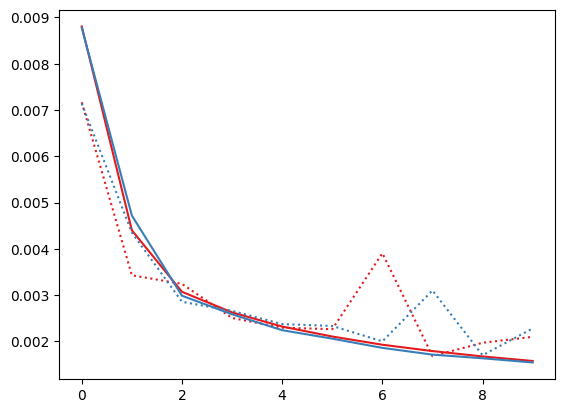

In [ ]:
cmap = plt.get_cmap('Set1')
for idx in range(K):
  plt.plot(range(num_epochs), all_fold_train_loss[idx], linestyle='-', color=cmap(idx))
  plt.plot(range(num_epochs), all_fold_val_loss[idx], linestyle=':', color=cmap(idx))
